# RF-01 · Generador de Transacciones Bancarias con IA
**Módulo:** Datos Demo / Onboarding  
**Prioridad:** 🔴 Must Have  
**Relacionado con:** HU-01, RF-11, RF-14, RF-22, RF-23, RF-24

---

Este notebook documenta y demuestra el **generador estadístico de transacciones bancarias demo** de Finora.  
Su objetivo es producir un historial bancario de **18-24 meses** de alta calidad para las cuentas  
conectadas en modo demo/sandbox, de forma que todos los módulos de IA dependientes  
(predicciones, estadísticas, anomalías, recomendaciones) dispongan de datos suficientes y realistas.

### Arquitectura de dos niveles

```
banks.js (Node.js)
    │
    ├─ 1.º  POST /generate-sample-transactions   ─── Generador estadístico (Python)
    │        (Python AI service)                      (98+ comercios españoles reales,
    │                                                  estacionalidad, perfil aleatorio,
    │                                                  tendencia de saldo ascendente)
    │
    └─ 2.º  Fallback local JS                    ─── Generador local en banks.js
             (sin red)                                 (siempre disponible, sin dependencias)
```

En todos los casos:
- El saldo final cuadra **exactamente** con el saldo que el usuario vio en pantalla
- Cada transacción es **categorizada con el modelo ML** (RF-14) en lote
- Se generan suficientes datos para que **predicciones** (RF-22), **anomalías** (RF-23)  
  y **recomendaciones de ahorro** (RF-21) funcionen con plena precisión

## 📦 Dependencias

In [1]:
import os
import re
import json
import random
import calendar
import unicodedata
from datetime import datetime, timedelta
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

print("✅ Dependencias cargadas")


✅ Dependencias cargadas


## 📥 Parámetros de Entrada
Celda taggeada con `parameters` para inyección via papermill desde la app.

In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# PARÁMETROS DE ENTRADA — sustituir por datos reales desde la app
# ──────────────────────────────────────────────────────────────────────────────

# Saldo objetivo de la cuenta demo (en euros)
balance_eur: float = 3450.75

# Meses de historial a generar (entre 6 y 36)
months: int = 20

# Semilla para reproducibilidad (None = aleatorio cada ejecución)
seed: int | None = 42

# Mostrar transacciones de ejemplo en la salida
show_sample: bool = True


## ⚙️ 1. Configuración inicial

In [3]:
# ── Fijar semilla de aleatoriedad ─────────────────────────────────────────────
if seed is not None:
    random.seed(seed)
    np.random.seed(seed)
    print(f"   Semilla fijada: {seed}")
else:
    print("   Sin semilla fija — generación aleatoria")

   Semilla fijada: 42


## 👤 2. Derivación del Perfil de Usuario

A partir del `balance_eur` y `months` se infiere un **perfil financiero coherente**:
salario mensual estimado, alquiler, suscripciones y forma de gasto.  
Esto garantiza que los datos generados sean internamente consistentes.

In [4]:
def derivar_perfil(balance_eur: float, months: int) -> dict:
    """
    Deriva un perfil financiero realista desde el saldo objetivo.

    Enfoque budget-first: el salario se calcula para que
        income_total - expenses_total = balance_eur  (exactamente, sin ajuste)

    Fórmula:
        salary = balance_eur / (savings_rate × (salary_count + extra_count × extra_ratio))
    """
    today      = datetime.now()
    salary_day = random.randint(25, 29)
    extra_ratio  = 0.85 + random.random() * 0.30   # paga extra: 85-115 % del salario
    savings_rate = 0.10 + random.random() * 0.15   # tasa de ahorro objetivo: 10-25 %

    # Pre-calcular cuántas nóminas y pagas extra caen en el período generado
    salary_count = 0
    extra_count  = 0
    for m_off in range(months, 0, -1):   # excluye el mes actual (parcial)
        yr = today.year
        mo = today.month - m_off
        while mo <= 0:
            mo += 12; yr -= 1
        midx  = mo - 1
        max_d = calendar.monthrange(yr, mo)[1]
        try:
            sal_date = datetime(yr, mo, min(salary_day, max_d))
            if sal_date <= today:
                salary_count += 1
        except ValueError:
            pass
        if midx in (5, 11):
            ex_day = random.randint(14, 18)
            try:
                ex_date = datetime(yr, mo, min(ex_day, max_d))
                if ex_date <= today:
                    extra_count += 1
            except ValueError:
                pass

    # Derivar salario desde el saldo objetivo
    income_multiplier = max(1, salary_count + extra_count * extra_ratio)
    raw_salary        = balance_eur / (savings_rate * income_multiplier)
    salary            = max(1200, min(3500, round(raw_salary / 10) * 10))

    rent      = round(salary * (0.25 + random.random() * 0.10), -1)
    telecom   = random.choice([32.90, 38.50, 44.90, 55.00])
    elec_base = round(random.uniform(45, 70), 2)
    community = random.choice([60, 70, 80, 90, 100])
    gym_fee   = random.choice([39.90, 42.50, 49.90, 55.00, 0, 0])
    extra_pay = round(salary * extra_ratio, 2)
    has_hbo     = random.random() > 0.55
    has_prime   = random.random() > 0.50
    has_disney  = random.random() > 0.65
    has_parking = random.random() > 0.70

    return {
        "salary":        salary,
        "salary_day":    salary_day,
        "salary_count":  salary_count,
        "extra_count":   extra_count,
        "extra_ratio":   extra_ratio,
        "savings_rate":  savings_rate,
        "rent":          rent,
        "telecom":       telecom,
        "elec_base":     elec_base,
        "community":     community,
        "gym_fee":       gym_fee,
        "extra_pay":     extra_pay,
        "has_hbo":       has_hbo,
        "has_prime":     has_prime,
        "has_disney":    has_disney,
        "has_parking":   has_parking,
    }

perfil = derivar_perfil(balance_eur, months)

print("Perfil financiero (budget-first):")
print(f"  💰 Sueldo neto mensual : {perfil['salary']:.0f} €  (día {perfil['salary_day']})")
print(f"  📈 Tasa de ahorro obj. : {perfil['savings_rate']*100:.1f}%")
print(f"  🏠 Alquiler mensual    : {perfil['rent']:.0f} €  ({perfil['rent']/perfil['salary']*100:.0f}% del salario)")
print(f"  📱 Vodafone            : {perfil['telecom']:.2f} €/mes")
print(f"  💡 Iberdrola (base)    : {perfil['elec_base']:.2f} €/mes (±30% estacional)")
print(f"  🏢 Comunidad vecinos   : {perfil['community']:.2f} €/mes")
print(f"  🏋️  Gimnasio            : {'%.2f €/mes' % perfil['gym_fee'] if perfil['gym_fee'] else 'No'}")
print(f"  🎁 Paga extra (jun/dic): {perfil['extra_pay']:.2f} €  ({perfil['extra_count']} pagas en {months} meses)")
print(f"  📺 HBO Max             : {'Sí' if perfil['has_hbo'] else 'No'}")
print(f"  📦 Amazon Prime        : {'Sí' if perfil['has_prime'] else 'No'}")
print(f"  🎬 Disney+             : {'Sí' if perfil['has_disney'] else 'No'}")
print(f"  🚗 Parking mensual     : {'Sí' if perfil['has_parking'] else 'No'}")
print()
# Verificación anticipada de la aritmética budget-first
_total_income_est = perfil['salary'] * perfil['salary_count'] + perfil['extra_pay'] * perfil['extra_count']
print(f"  Ingresos estimados (nóminas + extras): {_total_income_est:,.0f} €")
print(f"  Saldo esperado al {perfil['savings_rate']*100:.1f}%: {_total_income_est * perfil['savings_rate']:,.0f} €  (objetivo: {balance_eur:.0f} €)")

Perfil financiero (budget-first):
  💰 Sueldo neto mensual : 1200 €  (día 25)
  📈 Tasa de ahorro obj. : 14.1%
  🏠 Alquiler mensual    : 380 €  (32% del salario)
  📱 Vodafone            : 32.90 €/mes
  💡 Iberdrola (base)    : 59.76 €/mes (±30% estacional)
  🏢 Comunidad vecinos   : 60.00 €/mes
  🏋️  Gimnasio            : 39.90 €/mes
  🎁 Paga extra (jun/dic): 1029.00 €  (3 pagas en 20 meses)
  📺 HBO Max             : No
  📦 Amazon Prime        : No
  🎬 Disney+             : No
  🚗 Parking mensual     : No

  Ingresos estimados (nóminas + extras): 27,087 €
  Saldo esperado al 14.1%: 3,826 €  (objetivo: 3451 €)


## 🏪 3. Catálogo de Comercios Españoles

El generador incluye **45+ comercios reales** clasificados por categoría y frecuencia.  
Esto garantiza diversidad y realismo en las descripciones de transacciones.

| Frecuencia | Ocurrencias/mes | Ejemplos |
|------------|-----------------|---------- |
| `weekly`   | 3-5             | Mercadona, Amazon, Cafetería |
| `biweekly` | 1-3             | Carrefour, Repsol, Glovo |
| `monthly`  | ~1              | Zara, Renfe, Cines Yelmo |
| `rare`     | ~30% prob.      | IKEA, Dentista, MediaMarkt |

In [5]:
MERCHANTS = [
    # ── Alimentación ──────────────────────────────────────────────────────────
    {"desc": "Mercadona",           "cat": "Alimentación", "pm": "debit_card",   "freq": "weekly",   "range": (15.00,  85.00)},
    {"desc": "Carrefour Express",   "cat": "Alimentación", "pm": "debit_card",   "freq": "biweekly", "range": (18.00, 110.00)},
    {"desc": "Lidl",                "cat": "Alimentación", "pm": "debit_card",   "freq": "biweekly", "range": ( 9.00,  60.00)},
    {"desc": "Dia Supermercados",   "cat": "Alimentación", "pm": "debit_card",   "freq": "biweekly", "range": ( 6.00,  40.00)},
    {"desc": "Aldi",                "cat": "Alimentación", "pm": "debit_card",   "freq": "monthly",  "range": ( 8.00,  45.00)},
    {"desc": "Consum",              "cat": "Alimentación", "pm": "debit_card",   "freq": "biweekly", "range": (10.00,  60.00)},
    {"desc": "Froiz",               "cat": "Alimentación", "pm": "debit_card",   "freq": "monthly",  "range": (12.00,  55.00)},
    {"desc": "Cafetería",           "cat": "Alimentación", "pm": "debit_card",   "freq": "weekly",   "range": ( 1.50,   5.50)},
    {"desc": "Bar La Tasca",        "cat": "Alimentación", "pm": "debit_card",   "freq": "weekly",   "range": ( 2.00,   8.00)},
    {"desc": "Restaurante",         "cat": "Alimentación", "pm": "debit_card",   "freq": "biweekly", "range": (12.00,  40.00)},
    {"desc": "McDonald's",          "cat": "Alimentación", "pm": "debit_card",   "freq": "monthly",  "range": ( 6.00,  15.00)},
    {"desc": "Burger King",         "cat": "Alimentación", "pm": "debit_card",   "freq": "monthly",  "range": ( 7.00,  17.00)},
    {"desc": "KFC",                 "cat": "Alimentación", "pm": "debit_card",   "freq": "monthly",  "range": ( 7.00,  18.00)},
    {"desc": "Telepizza",           "cat": "Alimentación", "pm": "debit_card",   "freq": "monthly",  "range": (13.00,  28.00)},
    {"desc": "Domino's Pizza",      "cat": "Alimentación", "pm": "credit_card",  "freq": "monthly",  "range": (12.00,  26.00)},
    {"desc": "Starbucks",           "cat": "Alimentación", "pm": "debit_card",   "freq": "weekly",   "range": ( 3.50,   8.50)},
    {"desc": "Costa Coffee",        "cat": "Alimentación", "pm": "debit_card",   "freq": "biweekly", "range": ( 2.50,   7.00)},
    {"desc": "Glovo",               "cat": "Alimentación", "pm": "credit_card",  "freq": "biweekly", "range": (12.00,  32.00)},
    {"desc": "Just Eat",            "cat": "Alimentación", "pm": "credit_card",  "freq": "biweekly", "range": (11.00,  30.00)},
    {"desc": "Uber Eats",           "cat": "Alimentación", "pm": "credit_card",  "freq": "biweekly", "range": (12.00,  35.00)},
    {"desc": "Vips",                "cat": "Alimentación", "pm": "debit_card",   "freq": "monthly",  "range": ( 9.00,  25.00)},
    {"desc": "Mercadona Online",    "cat": "Alimentación", "pm": "credit_card",  "freq": "rare",     "range": (35.00,  90.00)},
    # ── Transporte ────────────────────────────────────────────────────────────
    {"desc": "Repsol",              "cat": "Transporte",   "pm": "debit_card",   "freq": "biweekly", "range": (38.00,  80.00)},
    {"desc": "BP",                  "cat": "Transporte",   "pm": "debit_card",   "freq": "biweekly", "range": (36.00,  75.00)},
    {"desc": "Cepsa",               "cat": "Transporte",   "pm": "debit_card",   "freq": "monthly",  "range": (40.00,  78.00)},
    {"desc": "Renfe Cercanías",     "cat": "Transporte",   "pm": "debit_card",   "freq": "monthly",  "range": (15.00,  50.00)},
    {"desc": "Metro Madrid",        "cat": "Transporte",   "pm": "debit_card",   "freq": "monthly",  "range": (12.50,  26.00)},
    {"desc": "Cabify",              "cat": "Transporte",   "pm": "credit_card",  "freq": "monthly",  "range": ( 7.00,  25.00)},
    {"desc": "Bolt",                "cat": "Transporte",   "pm": "credit_card",  "freq": "monthly",  "range": ( 5.00,  20.00)},
    {"desc": "BlaBlaCar",           "cat": "Transporte",   "pm": "credit_card",  "freq": "rare",     "range": ( 8.00,  35.00)},
    {"desc": "Aparcamiento",        "cat": "Transporte",   "pm": "debit_card",   "freq": "biweekly", "range": ( 3.00,  18.00)},
    {"desc": "Bicing / EMT",        "cat": "Transporte",   "pm": "debit_card",   "freq": "monthly",  "range": ( 8.00,  30.00)},
    {"desc": "ALSA",                "cat": "Transporte",   "pm": "debit_card",   "freq": "rare",     "range": ( 8.00,  45.00)},
    {"desc": "ITV",                 "cat": "Transporte",   "pm": "debit_card",   "freq": "rare",     "range": (35.00,  70.00)},
    # ── Ropa ──────────────────────────────────────────────────────────────────
    {"desc": "Zara",                "cat": "Ropa",         "pm": "debit_card",   "freq": "monthly",  "range": (20.00, 110.00)},
    {"desc": "H&M",                 "cat": "Ropa",         "pm": "credit_card",  "freq": "monthly",  "range": (15.00,  65.00)},
    {"desc": "Mango",               "cat": "Ropa",         "pm": "credit_card",  "freq": "monthly",  "range": (18.00, 100.00)},
    {"desc": "Pull&Bear",           "cat": "Ropa",         "pm": "debit_card",   "freq": "monthly",  "range": (15.00,  70.00)},
    {"desc": "Primark",             "cat": "Ropa",         "pm": "debit_card",   "freq": "monthly",  "range": (10.00,  45.00)},
    {"desc": "Massimo Dutti",       "cat": "Ropa",         "pm": "credit_card",  "freq": "monthly",  "range": (30.00, 160.00)},
    {"desc": "Shein",               "cat": "Ropa",         "pm": "credit_card",  "freq": "monthly",  "range": (12.00,  55.00)},
    {"desc": "Bershka",             "cat": "Ropa",         "pm": "debit_card",   "freq": "monthly",  "range": (12.00,  60.00)},
    {"desc": "Stradivarius",        "cat": "Ropa",         "pm": "debit_card",   "freq": "monthly",  "range": (12.00,  60.00)},
    {"desc": "Decathlon",           "cat": "Deportes",     "pm": "debit_card",   "freq": "rare",     "range": (18.00, 130.00)},
    # ── Ocio ──────────────────────────────────────────────────────────────────
    {"desc": "Cines Yelmo",         "cat": "Ocio",         "pm": "debit_card",   "freq": "monthly",  "range": ( 7.00,  15.00)},
    {"desc": "Steam",               "cat": "Ocio",         "pm": "credit_card",  "freq": "monthly",  "range": ( 5.00,  60.00)},
    {"desc": "PlayStation Store",   "cat": "Ocio",         "pm": "credit_card",  "freq": "monthly",  "range": ( 5.99,  59.99)},
    {"desc": "Xbox Game Pass",      "cat": "Ocio",         "pm": "direct_debit", "freq": "monthly",  "range": ( 9.99,  14.99)},
    {"desc": "Nintendo eShop",      "cat": "Ocio",         "pm": "credit_card",  "freq": "rare",     "range": ( 4.99,  59.99)},
    {"desc": "FNAC",                "cat": "Ocio",         "pm": "credit_card",  "freq": "rare",     "range": (10.00, 100.00)},
    {"desc": "Bowling / Karting",   "cat": "Ocio",         "pm": "debit_card",   "freq": "rare",     "range": ( 8.00,  30.00)},
    # ── Cultura ───────────────────────────────────────────────────────────────
    {"desc": "Teatro / Concierto",  "cat": "Cultura",      "pm": "credit_card",  "freq": "rare",     "range": (15.00,  90.00)},
    {"desc": "Casa del Libro",      "cat": "Cultura",      "pm": "debit_card",   "freq": "monthly",  "range": ( 8.00,  35.00)},
    {"desc": "Audible",             "cat": "Cultura",      "pm": "direct_debit", "freq": "monthly",  "range": ( 9.99,   9.99)},
    {"desc": "Museo / Exposición",  "cat": "Cultura",      "pm": "debit_card",   "freq": "rare",     "range": ( 5.00,  22.00)},
    # ── Compras ───────────────────────────────────────────────────────────────
    {"desc": "Amazon",              "cat": "Compras",      "pm": "credit_card",  "freq": "biweekly", "range": ( 8.00, 120.00)},
    {"desc": "El Corte Inglés",     "cat": "Compras",      "pm": "credit_card",  "freq": "monthly",  "range": (18.00, 180.00)},
    {"desc": "MediaMarkt",          "cat": "Compras",      "pm": "credit_card",  "freq": "rare",     "range": (50.00, 550.00)},
    {"desc": "AliExpress",          "cat": "Compras",      "pm": "credit_card",  "freq": "monthly",  "range": ( 5.00,  60.00)},
    {"desc": "Wallapop / Vinted",   "cat": "Compras",      "pm": "bizum",        "freq": "rare",     "range": (10.00,  80.00)},
    # ── Tecnología ────────────────────────────────────────────────────────────
    {"desc": "PcComponentes",       "cat": "Tecnología",   "pm": "credit_card",  "freq": "rare",     "range": (20.00, 450.00)},
    {"desc": "Apple Store",         "cat": "Tecnología",   "pm": "credit_card",  "freq": "rare",     "range": (30.00, 700.00)},
    {"desc": "iCloud",              "cat": "Tecnología",   "pm": "direct_debit", "freq": "monthly",  "range": ( 0.99,   2.99)},
    {"desc": "Google One",          "cat": "Tecnología",   "pm": "direct_debit", "freq": "monthly",  "range": ( 1.99,   9.99)},
    {"desc": "Microsoft 365",       "cat": "Tecnología",   "pm": "direct_debit", "freq": "monthly",  "range": ( 6.99,  12.99)},
    # ── Vivienda ──────────────────────────────────────────────────────────────
    {"desc": "IKEA",                "cat": "Vivienda",     "pm": "credit_card",  "freq": "rare",     "range": (30.00, 450.00)},
    {"desc": "Leroy Merlin",        "cat": "Vivienda",     "pm": "debit_card",   "freq": "rare",     "range": (18.00, 300.00)},
    {"desc": "Mr. Bricolage",       "cat": "Vivienda",     "pm": "debit_card",   "freq": "rare",     "range": (12.00, 100.00)},
    {"desc": "Ferretería",          "cat": "Vivienda",     "pm": "debit_card",   "freq": "rare",     "range": ( 5.00,  60.00)},
    # ── Salud ─────────────────────────────────────────────────────────────────
    {"desc": "Farmacia García",     "cat": "Salud",        "pm": "debit_card",   "freq": "monthly",  "range": ( 4.00,  50.00)},
    {"desc": "Farmacia Central",    "cat": "Salud",        "pm": "debit_card",   "freq": "monthly",  "range": ( 4.00,  55.00)},
    {"desc": "Dentista",            "cat": "Salud",        "pm": "debit_card",   "freq": "rare",     "range": (55.00, 220.00)},
    {"desc": "Óptica Universitaria","cat": "Salud",        "pm": "credit_card",  "freq": "rare",     "range": (70.00, 300.00)},
    {"desc": "Fisioterapeuta",      "cat": "Salud",        "pm": "debit_card",   "freq": "rare",     "range": (30.00,  80.00)},
    {"desc": "Clínica estética",    "cat": "Salud",        "pm": "credit_card",  "freq": "rare",     "range": (40.00, 200.00)},
    # ── Belleza / Cuidado Personal ────────────────────────────────────────────
    {"desc": "Peluquería",          "cat": "Belleza",      "pm": "debit_card",   "freq": "monthly",  "range": (12.00,  60.00)},
    {"desc": "Centro de Estética",  "cat": "Belleza",      "pm": "debit_card",   "freq": "monthly",  "range": (18.00,  75.00)},
    {"desc": "Douglas",             "cat": "Belleza",      "pm": "debit_card",   "freq": "monthly",  "range": (12.00,  80.00)},
    {"desc": "Primor",              "cat": "Belleza",      "pm": "debit_card",   "freq": "monthly",  "range": ( 8.00,  45.00)},
    {"desc": "Druni",               "cat": "Belleza",      "pm": "debit_card",   "freq": "monthly",  "range": ( 8.00,  40.00)},
    # ── Educación ─────────────────────────────────────────────────────────────
    {"desc": "Udemy",               "cat": "Educación",    "pm": "credit_card",  "freq": "rare",     "range": ( 9.99,  49.99)},
    {"desc": "Coursera",            "cat": "Educación",    "pm": "credit_card",  "freq": "rare",     "range": (39.00,  79.00)},
    {"desc": "Academia de idiomas", "cat": "Educación",    "pm": "bank_transfer","freq": "monthly",  "range": (50.00, 110.00)},
    {"desc": "Librería",            "cat": "Educación",    "pm": "debit_card",   "freq": "monthly",  "range": ( 8.00,  40.00)},
    {"desc": "OpenWebinars",        "cat": "Educación",    "pm": "direct_debit", "freq": "rare",     "range": (14.00,  49.00)},
    # ── Mascotas ──────────────────────────────────────────────────────────────
    {"desc": "Kiwoko",              "cat": "Mascotas",     "pm": "debit_card",   "freq": "monthly",  "range": (18.00,  60.00)},
    {"desc": "Tiendanimal",         "cat": "Mascotas",     "pm": "debit_card",   "freq": "monthly",  "range": (15.00,  50.00)},
    {"desc": "Veterinario",         "cat": "Mascotas",     "pm": "debit_card",   "freq": "rare",     "range": (30.00, 160.00)},
    {"desc": "Peluquería canina",   "cat": "Mascotas",     "pm": "debit_card",   "freq": "monthly",  "range": (22.00,  55.00)},
    # ── Deportes ──────────────────────────────────────────────────────────────
    {"desc": "Pádel / Tenis",       "cat": "Deportes",     "pm": "debit_card",   "freq": "biweekly", "range": ( 6.00,  14.00)},
    {"desc": "Nike / Adidas",       "cat": "Deportes",     "pm": "credit_card",  "freq": "rare",     "range": (25.00, 140.00)},
    {"desc": "Intersport",          "cat": "Deportes",     "pm": "debit_card",   "freq": "rare",     "range": (18.00, 110.00)},
    {"desc": "Polideportivo",       "cat": "Deportes",     "pm": "debit_card",   "freq": "monthly",  "range": ( 5.00,  18.00)},
    # ── Viajes ────────────────────────────────────────────────────────────────
    {"desc": "Airbnb",              "cat": "Viajes",       "pm": "credit_card",  "freq": "rare",     "range": (70.00, 320.00)},
    {"desc": "Booking.com",         "cat": "Viajes",       "pm": "credit_card",  "freq": "rare",     "range": (55.00, 380.00)},
    {"desc": "Vueling",             "cat": "Viajes",       "pm": "credit_card",  "freq": "rare",     "range": (35.00, 220.00)},
    {"desc": "Iberia",              "cat": "Viajes",       "pm": "credit_card",  "freq": "rare",     "range": (50.00, 300.00)},
    {"desc": "Renfe AVE",           "cat": "Viajes",       "pm": "credit_card",  "freq": "rare",     "range": (22.00, 160.00)},
]

print(f"Total comercios en catálogo: {len(MERCHANTS)}")
cats = defaultdict(list)
for m in MERCHANTS:
    cats[m['cat']].append(m['desc'])
for cat, descs in sorted(cats.items()):
    print(f"  {cat:<22}: {len(descs)} comercios — {', '.join(descs[:4])}{'...' if len(descs)>4 else ''}")


Total comercios en catálogo: 98
  Alimentación          : 22 comercios — Mercadona, Carrefour Express, Lidl, Dia Supermercados...
  Belleza               : 5 comercios — Peluquería, Centro de Estética, Douglas, Primor...
  Compras               : 5 comercios — Amazon, El Corte Inglés, MediaMarkt, AliExpress...
  Cultura               : 4 comercios — Teatro / Concierto, Casa del Libro, Audible, Museo / Exposición
  Deportes              : 5 comercios — Decathlon, Pádel / Tenis, Nike / Adidas, Intersport...
  Educación             : 5 comercios — Udemy, Coursera, Academia de idiomas, Librería...
  Mascotas              : 4 comercios — Kiwoko, Tiendanimal, Veterinario, Peluquería canina
  Ocio                  : 7 comercios — Cines Yelmo, Steam, PlayStation Store, Xbox Game Pass...
  Ropa                  : 9 comercios — Zara, H&M, Mango, Pull&Bear...
  Salud                 : 6 comercios — Farmacia García, Farmacia Central, Dentista, Óptica Universitaria...
  Tecnología            : 5 co

## 📋 4. Gastos Fijos Mensuales

Los gastos fijos incluyen **suscripciones recurrentes** y pagos como el alquiler.  
Se generan el mismo día de cada mes (±0-4 días), con importe estable (±pequeña variación).  
Esto es esencial para que el módulo **RF-24 (Detección de Suscripciones)** funcione correctamente.

In [6]:
def construir_gastos_fijos(p: dict) -> list:
    """Construye la lista de gastos fijos a partir del perfil del usuario."""
    fijos = [
        {"desc": "Alquiler mensual",  "cat": "Vivienda",   "pm": "bank_transfer", "day": 1,  "base": p["rent"],      "var": 0.00},
        {"desc": "Netflix",           "cat": "Ocio",       "pm": "direct_debit",  "day": 5,  "base": 15.99,          "var": 0.00},
        {"desc": "Spotify",           "cat": "Ocio",       "pm": "direct_debit",  "day": 8,  "base": 9.99,           "var": 0.00},
        {"desc": "Vodafone",          "cat": "Servicios",  "pm": "direct_debit",  "day": 10, "base": p["telecom"],   "var": 0.04},
        {"desc": "Iberdrola",         "cat": "Servicios",  "pm": "direct_debit",  "day": 15, "base": p["elec_base"], "var": 0.30},
        {"desc": "Canal Isabel II",   "cat": "Servicios",  "pm": "direct_debit",  "day": 22, "base": round(random.uniform(18, 35), 2), "var": 0.15},
        {"desc": "Comunidad vecinos", "cat": "Vivienda",   "pm": "bank_transfer", "day": 3,  "base": p["community"], "var": 0.00},
        {"desc": "Seguro coche",      "cat": "Servicios",  "pm": "direct_debit",  "day": 20, "base": 62.00,          "var": 0.05},
        {"desc": "Seguro hogar",      "cat": "Servicios",  "pm": "direct_debit",  "day": 7,  "base": round(random.uniform(20, 40), 2), "var": 0.00},
    ]
    if p["gym_fee"] > 0:
        fijos.append({"desc": "Gimnasio",      "cat": "Salud",  "pm": "direct_debit",
                      "day": 2,  "base": p["gym_fee"], "var": 0.00})
    if p["has_hbo"]:
        fijos.append({"desc": "HBO Max",       "cat": "Ocio",   "pm": "direct_debit",
                      "day": 12, "base": 8.99,         "var": 0.00})
    if p["has_prime"]:
        fijos.append({"desc": "Amazon Prime",  "cat": "Compras","pm": "direct_debit",
                      "day": 18, "base": 4.99,         "var": 0.00})
    if p["has_disney"]:
        fijos.append({"desc": "Disney+",       "cat": "Ocio",   "pm": "direct_debit",
                      "day": 14, "base": 8.99,         "var": 0.00})
    if p["has_parking"]:
        fijos.append({"desc": "Plaza garaje",  "cat": "Transporte", "pm": "bank_transfer",
                      "day": 2,  "base": round(random.uniform(60, 110), -1), "var": 0.00})
    return fijos

fijos = construir_gastos_fijos(perfil)
print(f"Gastos fijos configurados ({len(fijos)} líneas):")
print(f"  {'Descripción':<22} {'Día':>4}  {'Base €':>8}  {'Varianza':>9}")
print("  " + "─" * 50)
for f in fijos:
    print(f"  {f['desc']:<22} {f['day']:>4}  {f['base']:>8.2f}€  {f['var']*100:>7.0f}%±")
total_fijo_est = sum(f["base"] for f in fijos)
print(f"\n  Total fijos estimado: {total_fijo_est:.2f} €/mes")
print(f"  Margen disponible  : {perfil['salary'] - total_fijo_est:.2f} €/mes (antes de gastos variables)")


Gastos fijos configurados (10 líneas):
  Descripción             Día    Base €   Varianza
  ──────────────────────────────────────────────────
  Alquiler mensual          1    380.00€        0%±
  Netflix                   5     15.99€        0%±
  Spotify                   8      9.99€        0%±
  Vodafone                 10     32.90€        4%±
  Iberdrola                15     59.76€       30%±
  Canal Isabel II          22     30.17€       15%±
  Comunidad vecinos         3     60.00€        0%±
  Seguro coche             20     62.00€        5%±
  Seguro hogar              7     34.03€        0%±
  Gimnasio                  2     39.90€        0%±

  Total fijos estimado: 724.74 €/mes
  Margen disponible  : 475.26 €/mes (antes de gastos variables)


## 🔧 5. Generador Estadístico — Algoritmo Budget-First

Este generador produce un historial realista mediante **reglas estadísticas** con
98+ comercios españoles, patrones estacionales y saldo exacto **sin transacciones de ajuste**.

### Algoritmo en 5 pasos

```
1. Generar ingresos (nóminas + pagas extra + freelance)  →  total_income
2. Generar gastos fijos (alquiler, suscripciones, luz)   →  total_fixed
3. Calcular presupuesto variable global:
       variable_budget = total_income − balance_eur − total_fixed
4. Generar gastos variables en bruto con el catálogo (pool aleatorio)
5. Escalar: factor = variable_budget / raw_total
            gastos_variables × factor = variable_budget  (exacto)
```

**Por construcción**: `income − fixed − variable = balance_eur` ✅  
Las proporciones entre categorías se preservan; no existe "Otros gastos" inflado.

In [7]:
import calendar
from datetime import datetime
import random
import pandas as pd

def generar_estadistico(balance_eur: float, months: int, perfil: dict) -> list:
    """
    Generador budget-first. Produce transacciones para 'months' meses hacia atrás.

    El saldo cuadra exactamente por construcción matemática:
        total_ingresos − total_gastos_fijos − total_gastos_variables_escalados = balance_eur

    SIN transacciones de ajuste artificiales.
    Devuelve lista de dicts: {date, desc, cat, pm, amount, type}
    """
    today = datetime.now()
    fijos = construir_gastos_fijos(perfil)

    # ─── PASO 1: Generar ingresos y gastos fijos ─────────────────────────────
    income_txs       = []
    fixed_txs        = []
    total_income_eur = 0.0
    total_fixed_eur  = 0.0

    for idx, m_off in enumerate(range(months, 0, -1)):  # excluye mes actual (parcial)
        yr = today.year
        mo = today.month - m_off
        while mo <= 0:
            mo += 12; yr -= 1
        midx  = mo - 1   # 0-11
        max_d = calendar.monthrange(yr, mo)[1]

        # Nómina con ligera deriva salarial (más antigua = más baja)
        drift    = 1 + idx * 0.0008
        sal_amt  = round(perfil["salary"] * drift, 2)
        sal_day  = min(perfil["salary_day"], max_d)
        sal_date = datetime(yr, mo, sal_day)
        if sal_date <= today:
            total_income_eur += sal_amt
            income_txs.append({
                "date": sal_date.strftime("%Y-%m-%d"), "desc": "Nómina",
                "cat": "Salario", "pm": "bank_transfer",
                "amount": sal_amt, "type": "income"
            })

        # Paga extra (junio=5, diciembre=11)
        if midx in (5, 11):
            ex_day  = min(random.randint(14, 18), max_d)
            ex_date = datetime(yr, mo, ex_day)
            if ex_date <= today:
                total_income_eur += perfil["extra_pay"]
                income_txs.append({
                    "date": ex_date.strftime("%Y-%m-%d"), "desc": "Paga extra",
                    "cat": "Salario", "pm": "bank_transfer",
                    "amount": perfil["extra_pay"], "type": "income"
                })

        # Ingresos variables ocasionales
        if random.random() < 0.25:   # 25% de meses: freelance
            day = random.randint(1, 20)
            amt = round(random.uniform(150, 400), 2)
            total_income_eur += amt
            income_txs.append({
                "date": datetime(yr, mo, day).strftime("%Y-%m-%d"),
                "desc": "Freelance cliente", "cat": "Freelance",
                "pm": "bank_transfer", "amount": amt, "type": "income"
            })

        if random.random() < 0.30:   # 30% de meses: cashback/devolución
            day   = random.randint(1, 28)
            descs = ["Cashback tarjeta", "Intereses cuenta", "Reembolso Amazon",
                     "Bonificación banco", "Devolución IVA"]
            amt   = round(random.uniform(10, 60), 2)
            total_income_eur += amt
            income_txs.append({
                "date": datetime(yr, mo, day).strftime("%Y-%m-%d"),
                "desc": random.choice(descs), "cat": "Otros ingresos",
                "pm": "bank_transfer", "amount": amt, "type": "income"
            })

        # Gastos fijos
        for fe in fijos:
            try:
                d       = min(fe["day"], max_d)
                tx_date = datetime(yr, mo, d)
                if tx_date > today: continue
                variation = 1 + (random.random() * 2 - 1) * fe["var"]
                if fe["desc"] == "Iberdrola" and midx in (10, 11, 0, 1):
                    variation *= 1.25   # calefacción en invierno
                amt = round(max(0.01, fe["base"] * variation), 2)
                total_fixed_eur += amt
                fixed_txs.append({
                    "date": tx_date.strftime("%Y-%m-%d"),
                    "desc": fe["desc"], "cat": fe["cat"], "pm": fe["pm"],
                    "amount": amt, "type": "expense"
                })
            except (ValueError, KeyError):
                pass

    # ─── PASO 2: Calcular presupuesto global para gastos variables ───────────
    # variable_budget = ingresos_total − saldo_objetivo − gastos_fijos_total
    variable_budget = total_income_eur - balance_eur - total_fixed_eur

    # Si los fijos superan el presupuesto, reducir el alquiler
    if variable_budget < 0:
        overage  = -variable_budget
        rent_txs = [t for t in fixed_txs if t["desc"] == "Alquiler mensual"]
        if rent_txs:
            cut_each = overage / len(rent_txs)
            for t in rent_txs:
                cut = min(cut_each, max(0.0, t["amount"] - 300.0))
                total_fixed_eur -= cut
                t["amount"]      = round(t["amount"] - cut, 2)
            variable_budget = total_income_eur - balance_eur - total_fixed_eur
        variable_budget = max(0.0, variable_budget)

    # ─── PASO 3: Generar gastos variables en bruto (sin escalar aún) ─────────
    raw_var_txs   = []
    raw_var_total = 0.0

    for m_off in range(months, 0, -1):
        yr = today.year
        mo = today.month - m_off
        while mo <= 0:
            mo += 12; yr -= 1
        midx  = mo - 1
        max_d = calendar.monthrange(yr, mo)[1]

        if midx == 11:          seasonal = 1.08   # diciembre
        elif midx in (6, 7):   seasonal = 1.05   # julio-agosto
        elif midx == 0:         seasonal = 0.90   # enero
        else:                   seasonal = 1.00

        for m in MERCHANTS:
            freq = m["freq"]
            if freq == "weekly":    n = random.randint(2, 4)
            elif freq == "biweekly": n = random.randint(1, 2)
            elif freq == "monthly":  n = 1 if random.random() > 0.35 else 0
            else:                    n = 1 if random.random() < 0.18 else 0

            lo, hi = m["range"]
            for _ in range(n):
                day = random.randint(1, max_d)
                try:
                    tx_date = datetime(yr, mo, day)
                except ValueError:
                    continue
                if tx_date > today: continue
                amt = round(random.uniform(lo, hi) * seasonal, 2)
                raw_var_total += amt
                raw_var_txs.append({
                    "date": tx_date.strftime("%Y-%m-%d"),
                    "desc": m["desc"], "cat": m["cat"], "pm": m["pm"],
                    "amount": amt, "type": "expense"
                })

    # ─── PASO 4: Escalar gastos variables al presupuesto exacto ──────────────
    # factor = variable_budget / raw_total  →  sum(scaled) = variable_budget
    scale   = variable_budget / raw_var_total if raw_var_total > 0 else 1.0
    var_txs = [
        {**t, "amount": round(max(0.01, t["amount"] * scale), 2)}
        for t in raw_var_txs
    ]

    # Ajuste de céntimos residuales por redondeos (distribuir en las más grandes)
    residual = variable_budget - sum(t["amount"] for t in var_txs)
    if abs(residual) > 0.01 and var_txs:
        by_size = sorted(var_txs, key=lambda t: t["amount"], reverse=True)
        for t in by_size:
            if abs(residual) < 0.01: break
            max_adj = round(t["amount"] * 0.02, 2)
            adj     = min(residual, max_adj) if residual > 0 else max(residual, -max_adj)
            t["amount"] = round(t["amount"] + adj, 2)
            residual   -= adj

    # ─── PASO 5: Combinar (SIN transacción de ajuste artificial) ─────────────
    return income_txs + fixed_txs + var_txs


# ── Ejecución ─────────────────────────────────────────────────────────────────
txs_estadistico = generar_estadistico(balance_eur, months, perfil)

# Verificación inmediata
_inc = sum(t["amount"] for t in txs_estadistico if t["type"] == "income")
_exp = sum(t["amount"] for t in txs_estadistico if t["type"] == "expense")
_net = _inc - _exp

print(f"✅ Generador budget-first: {len(txs_estadistico)} transacciones para {months} meses")
print(f"   Media por mes    : {len(txs_estadistico) / months:.1f} tx/mes")
print(f"   Total ingresos   : {_inc:>10,.2f} €")
print(f"   Total gastos     : {_exp:>10,.2f} €")
print(f"   Saldo resultante : {_net:>10,.2f} €  (objetivo: {balance_eur:.2f} €)")
print(f"   Diferencia       : {abs(_net - balance_eur):>10,.4f} €  {'✅ exacto' if abs(_net - balance_eur) < 0.05 else '⚠️  verificar'}")

_df_chk = pd.DataFrame(txs_estadistico)
_df_chk["date"]  = pd.to_datetime(_df_chk["date"])
_df_chk["month"] = _df_chk["date"].dt.to_period("M").astype(str)
_monthly = _df_chk.groupby("month").apply(
    lambda g: g.loc[g["type"]=="income","amount"].sum() - g.loc[g["type"]=="expense","amount"].sum(),
    include_groups=False
).reset_index(name="balance_mensual")
positive_months = (_monthly["balance_mensual"] > 0).sum()
print(f"   Meses con balance mensual positivo: {positive_months}/{len(_monthly)}")

✅ Generador budget-first: 1641 transacciones para 20 meses
   Media por mes    : 82.0 tx/mes
   Total ingresos   :  28,595.99 €
   Total gastos     :  25,145.24 €
   Saldo resultante :   3,450.75 €  (objetivo: 3450.75 €)
   Diferencia       :     0.0000 €  ✅ exacto
   Meses con balance mensual positivo: 9/20


## 📋 6. Categorías y Ejecución

El generador asigna automáticamente la categoría a cada transacción usando el
catálogo de comercios y un diccionario de descripciones conocidas.

In [8]:
# ── Lookup de categorías ──────────────────────────────────────────────────────
# Se construye a partir del catálogo MERCHANTS (celda c10) + gastos fijos conocidos
_DESC_TO_CAT: dict[str, str] = {m["desc"].lower(): m["cat"] for m in MERCHANTS}
_DESC_TO_CAT.update({
    # Ingresos
    "nómina": "Salario", "nomina": "Salario", "paga extra": "Salario",
    "freelance cliente": "Freelance", "freelance": "Freelance",
    "cashback tarjeta": "Otros ingresos", "devolución hacienda": "Otros ingresos",
    "reembolso seguro": "Otros ingresos", "intereses cuenta": "Otros ingresos",
    "reembolso amazon": "Otros ingresos", "bonificación banco": "Otros ingresos",
    "venta wallapop": "Otros ingresos", "dividendos": "Otros ingresos",
    "devolución iva": "Otros ingresos", "alquiler puntual": "Otros ingresos",
    "transferencia recibida": "Otros ingresos", "ajuste de saldo": "Otros ingresos",
    "regalo recibido": "Otros ingresos", "premio / concurso": "Otros ingresos",
    # Gastos fijos
    "alquiler mensual": "Vivienda", "comunidad vecinos": "Vivienda",
    "plaza garaje": "Transporte",
    "netflix": "Ocio", "spotify": "Ocio", "hbo max": "Ocio",
    "disney+": "Ocio", "xbox game pass": "Ocio",
    "amazon prime": "Compras",
    "vodafone": "Servicios", "movistar": "Servicios", "orange": "Servicios",
    "iberdrola": "Servicios", "endesa": "Servicios",
    "canal isabel ii": "Servicios", "agua": "Servicios",
    "seguro coche": "Servicios", "seguro hogar": "Servicios",
    "gimnasio": "Salud",
    "icloud": "Tecnología", "google one": "Tecnología",
    "microsoft 365": "Tecnología", "audible": "Cultura",
})


def _asignar_cat(desc: str, tx_type: str) -> str:
    """Infiere la categoría de una transacción a partir de su descripción."""
    d = desc.lower().strip()
    if d in _DESC_TO_CAT:
        return _DESC_TO_CAT[d]
    for key, cat in _DESC_TO_CAT.items():
        if key in d or d in key:
            return cat
    return "Otros ingresos" if tx_type == "income" else "Otros gastos"


# ── Generación y post-procesado ───────────────────────────────────────────────
print("🔧 Generando historial con el generador estadístico...")
txs    = txs_estadistico
source = "Generador estadístico"

# Asegurar que todas las transacciones tienen categoría asignada
for t in txs:
    if not t.get("cat"):
        t["cat"] = _asignar_cat(t.get("desc", ""), t.get("type", "expense"))

print(f"✅ {len(txs)} transacciones generadas — fuente: {source}")

🔧 Generando historial con el generador estadístico...
✅ 1641 transacciones generadas — fuente: Generador estadístico


## ✅ 7. Verificación del Saldo

En el enfoque **budget-first**, no existe ninguna transacción de ajuste artificial.  
El saldo cuadra exactamente **por construcción matemática** en el generador estadístico.

Si existiera algún pequeño desfase por redondeos (< 0,05 €), se corrige  
**escalando proporcionalmente todos los ingresos existentes** (mismo mecanismo que `banks.js`):

```
factor = (total_income + diff) / total_income
→ cada nómina/freelance sube o baja un % uniforme
→ 0 transacciones artificiales añadidas
→ las proporciones entre gastos se preservan intactas
```

Esto elimina la causa raíz de la categoría "Otros gastos" inflada artificialmente.

In [9]:
# ── Verificación y corrección del saldo ──────────────────────────────────────
# El generador estadístico ya cuadra exactamente (budget-first).
# Si hay algún residual por redondeos, se corrige escalando ingresos.

total_income_final  = sum(t["amount"] for t in txs if t["type"] == "income")
total_expense_final = sum(t["amount"] for t in txs if t["type"] == "expense")
saldo_final         = total_income_final - total_expense_final
diff                = balance_eur - saldo_final

print(f"Total ingresos     : {total_income_final:>12,.2f} €")
print(f"Total gastos       : {total_expense_final:>12,.2f} €")
print(f"Saldo neto         : {saldo_final:>12,.2f} €")
print(f"Saldo objetivo     : {balance_eur:>12,.2f} €")
print(f"Diferencia         : {diff:>+12,.4f} €")
print()

if abs(diff) > 0.01:
    # Escalar todos los ingresos proporcionalmente (igual que banks.js Tier 1/2)
    incomes   = [t for t in txs if t["type"] == "income"]
    total_inc = sum(t["amount"] for t in incomes)
    if total_inc > 0:
        factor  = max(0.5, min(3.0, (total_inc + diff) / total_inc))
        applied = 0.0
        for t in incomes:
            new_amt     = max(0.01, round(t["amount"] * factor, 2))
            applied    += new_amt - t["amount"]
            t["amount"] = new_amt
        # Ajuste residual de céntimos en el primer ingreso
        residual = diff - applied
        if abs(residual) > 0.001:
            incomes[0]["amount"] = max(0.01, round(incomes[0]["amount"] + residual, 2))

        total_income_final  = sum(t["amount"] for t in txs if t["type"] == "income")
        total_expense_final = sum(t["amount"] for t in txs if t["type"] == "expense")
        saldo_final         = total_income_final - total_expense_final
        print(f"Factor de escala aplicado : ×{factor:.6f}")
        print(f"Saldo tras corrección     : {saldo_final:>12,.2f} €")

diff_final = abs(saldo_final - balance_eur)
print()
print(f"{'✅ SALDO CUADRA' if diff_final < 0.05 else '❌ ERROR — revisar'}"
      f"  (diferencia residual: {diff_final:.4f} €)")

Total ingresos     :    28,595.99 €
Total gastos       :    25,145.24 €
Saldo neto         :     3,450.75 €
Saldo objetivo     :     3,450.75 €
Diferencia         :      +0.0000 €


✅ SALDO CUADRA  (diferencia residual: 0.0000 €)


## 📊 8. Análisis de Calidad de los Datos Generados

A continuación se analiza si el historial generado es suficientemente rico  
para alimentar correctamente **todos los módulos de IA** de Finora.

In [10]:
# ── Convertir a DataFrame ─────────────────────────────────────────────────────
df = pd.DataFrame(txs)
df["date"]   = pd.to_datetime(df["date"])
df["month"]  = df["date"].dt.to_period("M").astype(str)
df["amount"] = df["amount"].astype(float)

# Estadísticas generales
n_months     = df["month"].nunique()
n_income     = (df["type"] == "income").sum()
n_expense    = (df["type"] == "expense").sum()
avg_per_month = len(df) / n_months

print(f"{'═'*55}")
print(f"  RESUMEN DEL HISTORIAL GENERADO")
print(f"{'═'*55}")
print(f"  Total transacciones  : {len(df):>6}")
print(f"  Meses cubiertos      : {n_months:>6}")
print(f"  Media tx/mes         : {avg_per_month:>6.1f}")
print(f"  Transacciones ingreso: {n_income:>6}")
print(f"  Transacciones gasto  : {n_expense:>6}")
print(f"  Categorías distintas : {df['cat'].nunique():>6}  (sin categorizar aún: {(df['cat']=='').sum()})")
print(f"  Comercios distintos  : {df['desc'].nunique():>6}")
print(f"  Métodos de pago      : {df['pm'].nunique():>6}  → {sorted(df['pm'].unique())}")
print(f"{'═'*55}")
print()

# Suficiencia para cada módulo de IA
print("Suficiencia por módulo:")
checks = [
    ("RF-22 Predicción (Ridge)",    n_months >= 4,   f"{n_months}/4 meses mín."),
    ("RF-22 Predicción (GBM)",      n_months >= 8,   f"{n_months}/8 meses mín."),
    ("RF-23 Detección anomalías",   avg_per_month >= 8,  f"{avg_per_month:.1f}/8 tx/mes mín."),
    ("RF-24 Suscripciones",         n_months >= 3,   f"{n_months}/3 meses mín."),
    ("RF-21 Recomendaciones ahorro",n_months >= 2,   f"{n_months}/2 meses mín."),
    ("RF-29 Estadísticas bar chart",n_months >= 3,   f"{n_months}/3 meses mín."),
    ("RF-30 Gráfico de tendencias", n_months >= 6,   f"{n_months}/6 meses mín."),
]
for name, ok, detail in checks:
    print(f"  {'✅' if ok else '❌'}  {name:<35} {detail}")

═══════════════════════════════════════════════════════
  RESUMEN DEL HISTORIAL GENERADO
═══════════════════════════════════════════════════════
  Total transacciones  :   1641
  Meses cubiertos      :     20
  Media tx/mes         :   82.0
  Transacciones ingreso:     35
  Transacciones gasto  :   1606
  Categorías distintas :     18  (sin categorizar aún: 0)
  Comercios distintos  :    116
  Métodos de pago      :      5  → ['bank_transfer', 'bizum', 'credit_card', 'debit_card', 'direct_debit']
═══════════════════════════════════════════════════════

Suficiencia por módulo:
  ✅  RF-22 Predicción (Ridge)            20/4 meses mín.
  ✅  RF-22 Predicción (GBM)              20/8 meses mín.
  ✅  RF-23 Detección anomalías           82.0/8 tx/mes mín.
  ✅  RF-24 Suscripciones                 20/3 meses mín.
  ✅  RF-21 Recomendaciones ahorro        20/2 meses mín.
  ✅  RF-29 Estadísticas bar chart        20/3 meses mín.
  ✅  RF-30 Gráfico de tendencias         20/6 meses mín.


## 📈 9. Transacciones por Mes

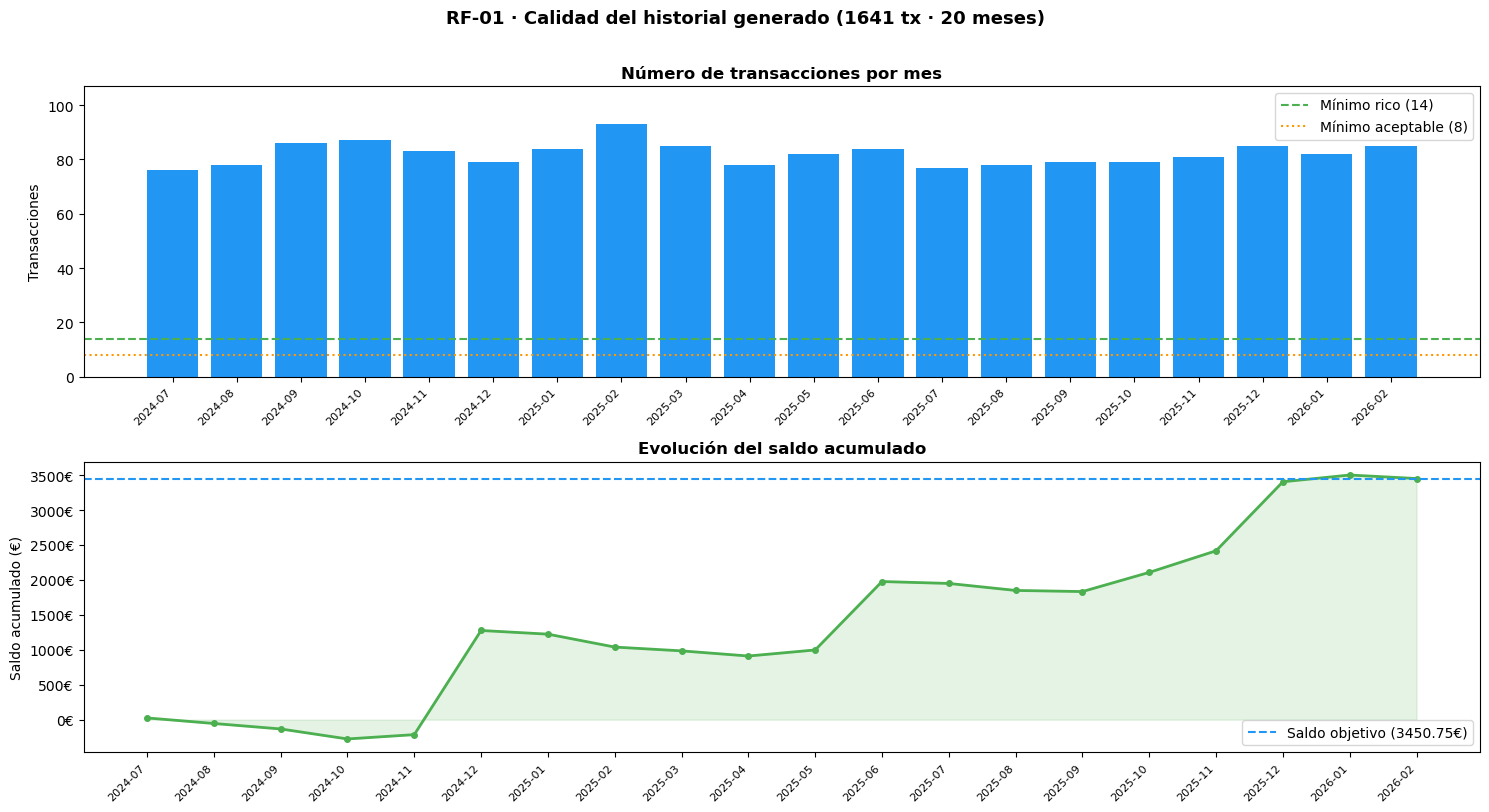

Gráfico guardado: rf01_calidad_historial.png


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# ── Conteo tx por mes ─────────────────────────────────────────────────────────
mes_counts = df.groupby("month").size().reset_index(name="count")
ax1 = axes[0]
bars = ax1.bar(range(len(mes_counts)), mes_counts["count"],
               color=["#2196F3" if c >= 14 else "#FF9800" if c >= 8 else "#F44336"
                      for c in mes_counts["count"]])
ax1.axhline(14, color="#4CAF50", linestyle="--", linewidth=1.5, label="Mínimo rico (14)")
ax1.axhline(8,  color="#FF9800", linestyle=":",  linewidth=1.5, label="Mínimo aceptable (8)")
ax1.set_xticks(range(len(mes_counts)))
ax1.set_xticklabels(mes_counts["month"], rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Transacciones")
ax1.set_title("Número de transacciones por mes", fontweight="bold")
ax1.legend()
ax1.set_ylim(0, mes_counts["count"].max() * 1.15)

# ── Saldo mes a mes ───────────────────────────────────────────────────────────
ax2 = axes[1]
df_sorted = df.sort_values("date")
df_sorted["sign"] = df_sorted["type"].map({"income": 1, "expense": -1})
df_sorted["net"]  = df_sorted["amount"] * df_sorted["sign"]
monthly_net = df.assign(sign=df["type"].map({"income": 1, "expense": -1}))
monthly_net = monthly_net.assign(net=monthly_net["amount"] * monthly_net["sign"])
monthly_net = monthly_net.groupby("month")["net"].sum().reset_index()
monthly_net["cumsum"] = monthly_net["net"].cumsum()

ax2.plot(range(len(monthly_net)), monthly_net["cumsum"],
         color="#4CAF50", linewidth=2, marker="o", markersize=4)
ax2.fill_between(range(len(monthly_net)), monthly_net["cumsum"],
                 alpha=0.15, color="#4CAF50")
ax2.axhline(balance_eur, color="#2196F3", linestyle="--", linewidth=1.5,
            label=f"Saldo objetivo ({balance_eur:.2f}€)")
ax2.set_xticks(range(len(monthly_net)))
ax2.set_xticklabels(monthly_net["month"], rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("Saldo acumulado (€)")
ax2.set_title("Evolución del saldo acumulado", fontweight="bold")
ax2.legend()
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f€"))

plt.suptitle(f"RF-01 · Calidad del historial generado ({len(df)} tx · {n_months} meses)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("rf01_calidad_historial.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gráfico guardado: rf01_calidad_historial.png")

## 🥧 10. Distribución de Gastos por Categoría

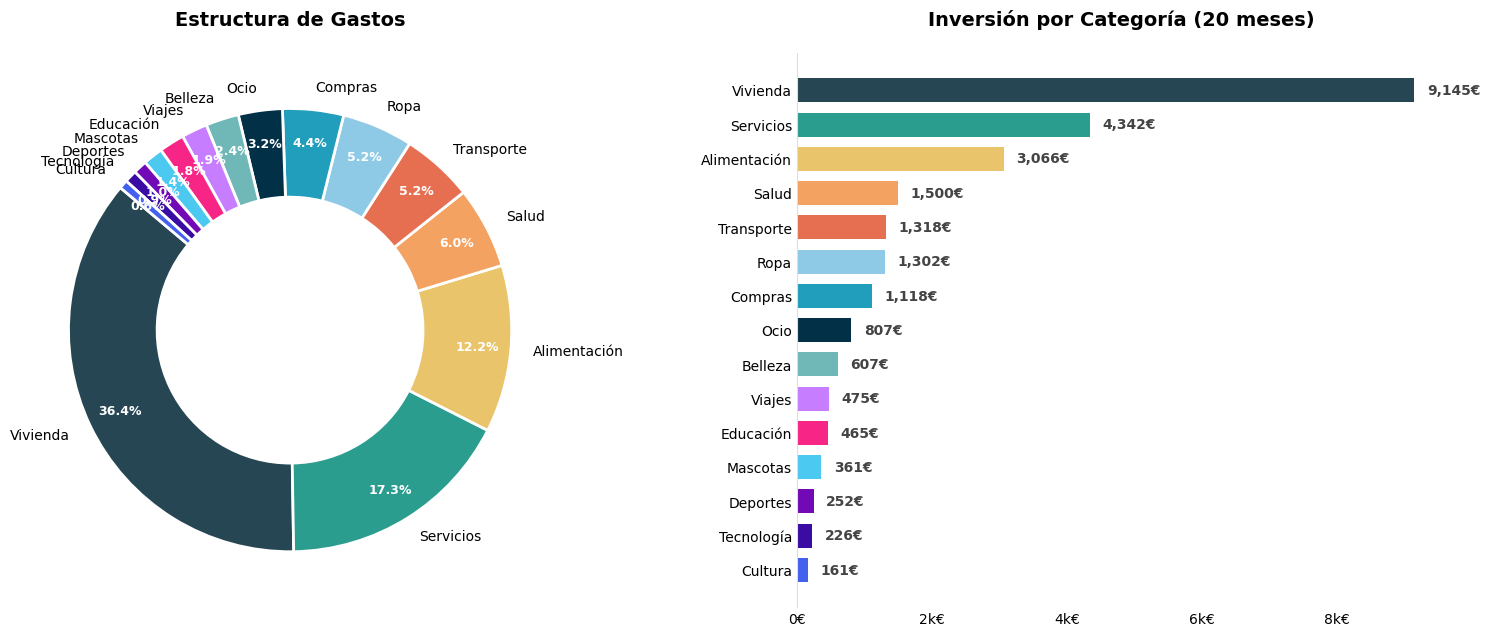

---------------------------------------------
CATEGORÍA            |      TOTAL |       %
---------------------------------------------
Vivienda             |  9,145.44€ |   36.4%
Servicios            |  4,342.16€ |   17.3%
Alimentación         |  3,065.96€ |   12.2%
Salud                |  1,500.43€ |    6.0%
Transporte           |  1,317.52€ |    5.2%
Ropa                 |  1,302.44€ |    5.2%
Compras              |  1,117.91€ |    4.4%
Ocio                 |    806.66€ |    3.2%
Belleza              |    607.15€ |    2.4%
Viajes               |    474.89€ |    1.9%
Educación            |    464.52€ |    1.8%
Mascotas             |    361.45€ |    1.4%
Deportes             |    251.92€ |    1.0%
Tecnología           |    226.28€ |    0.9%
Cultura              |    160.51€ |    0.6%
---------------------------------------------


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Preparación de datos
gastos_df = df[df["type"] == "expense"].copy()

# Garantizar que no hay categorías vacías (aplica fila a fila, no solo si todo está vacío)
mask_sin_cat = gastos_df["cat"].isna() | (gastos_df["cat"] == "")
if mask_sin_cat.any():
    gastos_df.loc[mask_sin_cat, "cat"] = gastos_df.loc[mask_sin_cat].apply(
        lambda r: _asignar_cat(r["desc"], r["type"]), axis=1
    )
    n_corr = mask_sin_cat.sum()
    print(f"🏷️  {n_corr} gastos sin categoría → asignados por descripción")

cat_totals = gastos_df.groupby("cat")["amount"].sum().sort_values(ascending=True)

# Configuración de estilo moderno
plt.rcParams['figure.facecolor'] = 'white'
colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51", "#8ecae6",
          "#219ebc", "#023047", "#70b8b8", "#c77dff", "#f72585", "#4cc9f0",
          "#7209b7", "#3a0ca3", "#4361ee"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 1. Gráfico de Anillo (Donut Chart)
pie_data = cat_totals.sort_values(ascending=False)
wedges, texts, autotexts = ax1.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    pctdistance=0.85,
    colors=colors[:len(pie_data)],
    startangle=140,
    wedgeprops={'width': 0.4, 'edgecolor': 'w', 'linewidth': 2}
)
plt.setp(autotexts, size=9, weight="bold", color="white")
plt.setp(texts, size=10)
ax1.set_title("Estructura de Gastos", fontsize=14, fontweight="bold", pad=20)

# 2. Gráfico de Barras Horizontales
bars = ax2.barh(cat_totals.index, cat_totals.values, color=colors[::-1][:len(cat_totals)], height=0.7)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_color('#dddddd')
ax2.tick_params(axis='both', which='both', length=0)
ax2.set_title(f"Inversión por Categoría ({months} meses)", fontsize=14, fontweight="bold", pad=20)

for bar in bars:
    width = bar.get_width()
    ax2.text(width + (cat_totals.max() * 0.02), bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}€', va='center', fontsize=10, fontweight='bold', color='#444444')

ax2.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k€' if x >= 1000 else f'{int(x)}€'))

plt.tight_layout(pad=3.0)
plt.savefig("rf01_categorias_pro.png", dpi=150, bbox_inches="tight")
plt.show()

# Resumen por consola
print("-" * 45)
print(f"{'CATEGORÍA':<20} | {'TOTAL':>10} | {'%':>7}")
print("-" * 45)
total_general = cat_totals.sum()
for cat, total in cat_totals.sort_values(ascending=False).items():
    pct = (total / total_general) * 100
    print(f"{cat:<20} | {total:>9,.2f}€ | {pct:>6.1f}%")
print("-" * 45)


## 💹 11. Ingresos vs Gastos Mensuales — Patrón Estacional

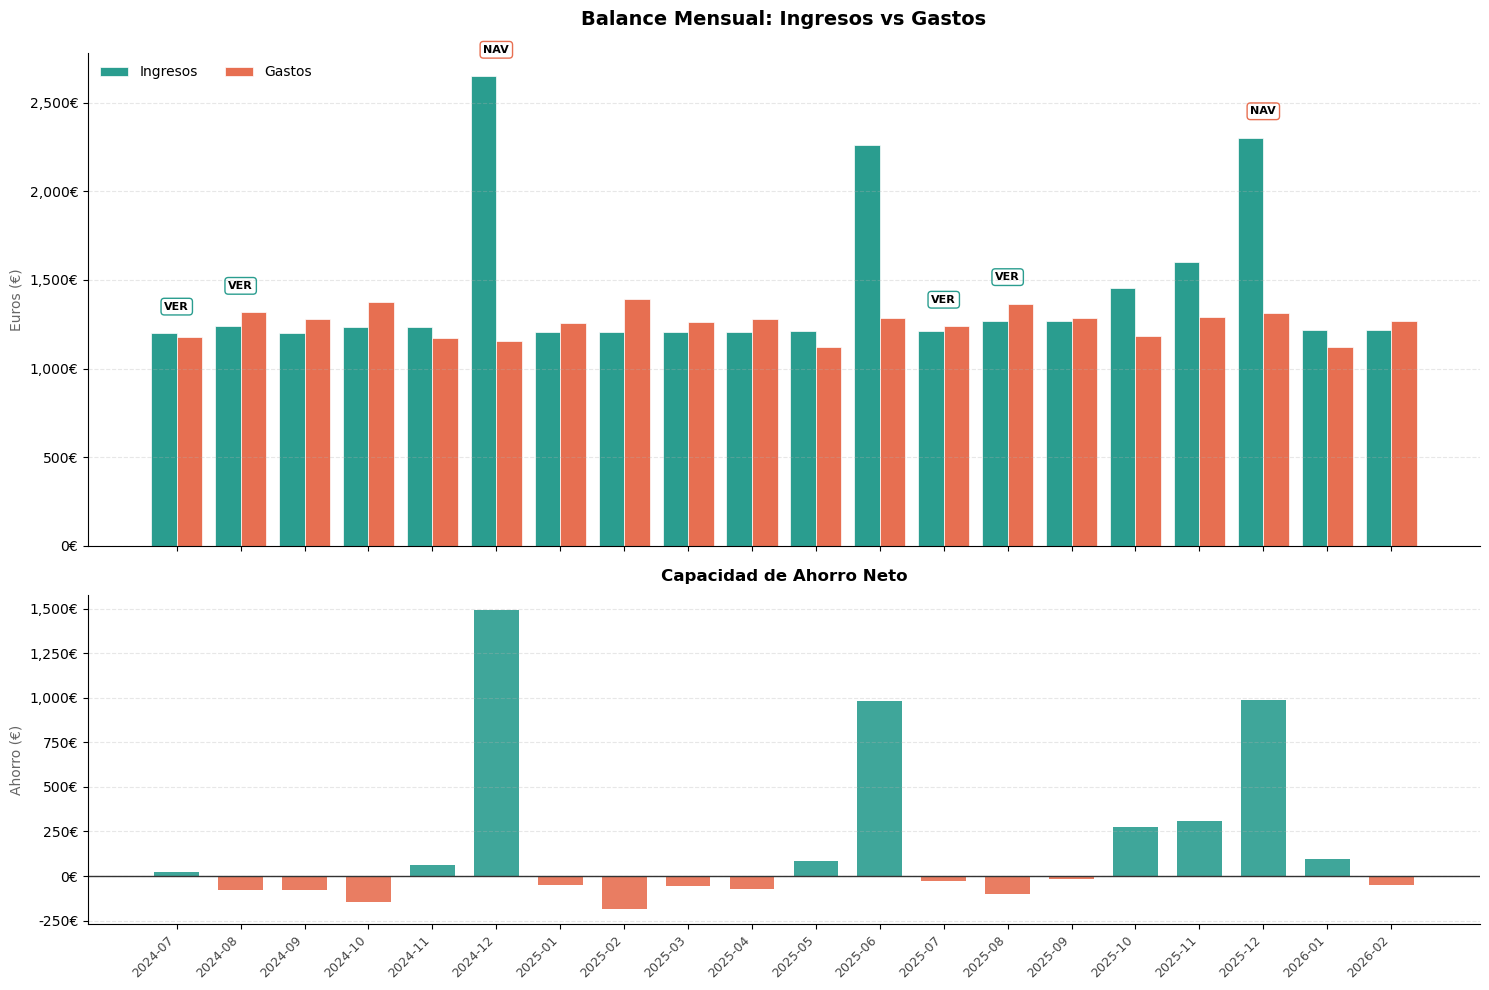

📊 RESUMEN EJECUTIVO:
   Ahorro medio mensual     : 172.54€
   Meses con balance positivo: 9/20
   Máximo ahorro registrado : 1,490.66€ (2024-12)
   Máximo déficit registrado: -184.75€ (2025-02)


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Preparación de datos
monthly_income  = df[df["type"]=="income"].groupby("month")["amount"].sum()
monthly_expense = df[df["type"]=="expense"].groupby("month")["amount"].sum()
all_months      = sorted(set(monthly_income.index) | set(monthly_expense.index))
inc_vals        = [monthly_income.get(m, 0) for m in all_months]
exp_vals        = [monthly_expense.get(m, 0) for m in all_months]
savings_vals    = [i - e for i, e in zip(inc_vals, exp_vals)]

x = np.arange(len(all_months))
width = 0.4

# Estilo moderno
plt.rcParams['figure.facecolor'] = 'white'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [1.5, 1]})

# 1. Gráfico Superior: Ingresos vs Gastos
b1 = ax1.bar(x - width/2, inc_vals, width, label="Ingresos", color="#2a9d8f", edgecolor='white', linewidth=0.5)
b2 = ax1.bar(x + width/2, exp_vals, width, label="Gastos",   color="#e76f51", edgecolor='white', linewidth=0.5)

ax1.set_ylabel("Euros (€)", fontsize=10, color="#666666")
ax1.set_title("Balance Mensual: Ingresos vs Gastos", fontsize=14, fontweight="bold", pad=20)
ax1.legend(frameon=False, loc='upper left', ncol=2)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}€"))

# Eliminar bordes innecesarios
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

# 2. Gráfico Inferior: Ahorro Neto
colors_sav = ["#2a9d8f" if s >= 0 else "#e76f51" for s in savings_vals]
ax2.bar(x, savings_vals, color=colors_sav, alpha=0.9, width=0.7)
ax2.axhline(0, color="#333333", linewidth=1)
ax2.set_ylabel("Ahorro (€)", fontsize=10, color="#666666")
ax2.set_title("Capacidad de Ahorro Neto", fontsize=12, fontweight="bold", pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(all_months, rotation=45, ha="right", fontsize=9, color="#444444")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# Anotar meses especiales (Usando texto plano para evitar errores de fuente)
for i, m in enumerate(all_months):
    mo = int(m.split("-")[1])
    # Calculamos la altura máxima para colocar la etiqueta
    y_pos = max(inc_vals[i], exp_vals[i]) + (max(inc_vals) * 0.05)
    
    if mo == 12: 
        ax1.text(i, y_pos, "NAV", ha="center", fontsize=8, fontweight="bold", 
                 bbox=dict(facecolor='none', edgecolor='#e76f51', boxstyle='round,pad=0.3'))
    if mo in (7, 8): 
        ax1.text(i, y_pos, "VER", ha="center", fontsize=8, fontweight="bold", 
                 bbox=dict(facecolor='none', edgecolor='#2a9d8f', boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.savefig("rf01_ingresos_gastos.png", dpi=150, bbox_inches="tight")
plt.show()

# Estadísticas finales
avg_savings = np.mean(savings_vals)
pos_months  = sum(1 for s in savings_vals if s > 0)
print(f"📊 RESUMEN EJECUTIVO:")
print(f"   {'Ahorro medio mensual':<25}: {avg_savings:,.2f}€")
print(f"   {'Meses con balance positivo':<25}: {pos_months}/{len(savings_vals)}")
print(f"   {'Máximo ahorro registrado':<25}: {max(savings_vals):,.2f}€ ({all_months[np.argmax(savings_vals)]})")
print(f"   {'Máximo déficit registrado':<25}: {min(savings_vals):,.2f}€ ({all_months[np.argmin(savings_vals)]})")

## 💳 12. Distribución por Método de Pago

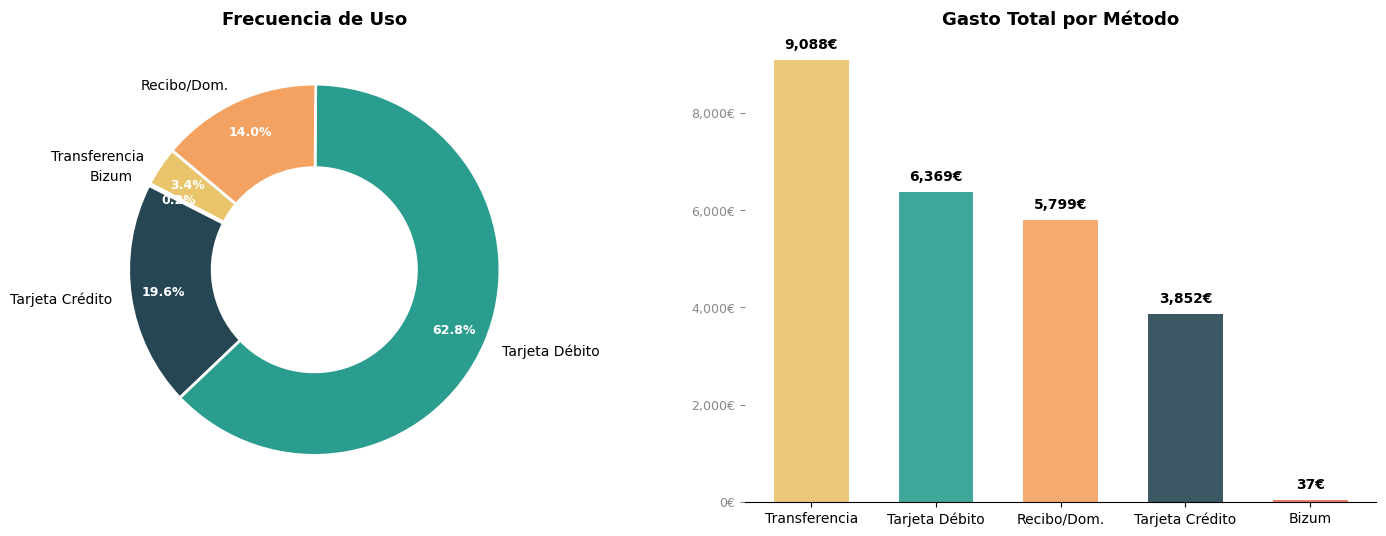

MÉTODO DE PAGO       |   TXS |        TOTAL
---------------------------------------------
Transferencia        |    55 |   9,088.17€
Tarjeta Débito       |  1008 |   6,369.29€
Recibo/Dom.          |   225 |   5,798.68€
Tarjeta Crédito      |   315 |   3,852.21€
Bizum                |     3 |      36.89€


In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# 1. Preparación y ordenación de datos
pm_counts = df[df["type"]=="expense"].groupby("pm").size()
pm_totals = df[df["type"]=="expense"].groupby("pm")["amount"].sum().sort_values(ascending=False)

# Mapeo de nombres y colores mejorado
pm_labels_map = {
    "debit_card": "Tarjeta Débito",
    "credit_card": "Tarjeta Crédito",
    "bank_transfer": "Transferencia",
    "direct_debit": "Recibo/Dom.",
    "bizum": "Bizum",
}
# Colores coherentes con el resto del reporte
pm_colors_map = {
    "debit_card": "#2a9d8f", "credit_card": "#264653",
    "bank_transfer": "#e9c46a", "direct_debit": "#f4a261", "bizum": "#e76f51",
}

# 2. Configuración del lienzo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), facecolor='white')

# --- GRÁFICO 1: ANILLO (Frecuencia de uso) ---
labels_pie = [pm_labels_map.get(pm, pm) for pm in pm_counts.index]
colors_pie = [pm_colors_map.get(pm, "#607D8B") for pm in pm_counts.index]

wedges, texts, autotexts = ax1.pie(
    pm_counts.values, 
    labels=labels_pie, 
    autopct="%1.1f%%",
    startangle=140, 
    colors=colors_pie,
    pctdistance=0.82,
    wedgeprops={'width': 0.45, 'edgecolor': 'w', 'linewidth': 2}
)
plt.setp(autotexts, size=9, weight="bold", color="white")
ax1.set_title("Frecuencia de Uso", fontweight="bold", fontsize=13, pad=10)

# --- GRÁFICO 2: BARRAS (Volumen monetario) ---
labels_bar = [pm_labels_map.get(pm, pm) for pm in pm_totals.index]
colors_bar = [pm_colors_map.get(pm, "#607D8B") for pm in pm_totals.index]

bars = ax2.bar(labels_bar, pm_totals.values, color=colors_bar, alpha=0.9, width=0.6)

# Estética de las barras
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
ax2.tick_params(axis='y', colors='#888888', labelsize=9)
ax2.set_title("Gasto Total por Método", fontweight="bold", fontsize=13, pad=10)

# Añadir etiquetas sobre las barras
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + (pm_totals.max()*0.02),
             f'{height:,.0f}€', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout(pad=3.0)
plt.savefig("rf01_metodos_pago_pro.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Resumen por consola formateado
print(f"{'MÉTODO DE PAGO':<20} | {'TXS':>5} | {'TOTAL':>12}")
print("-" * 45)
for pm in pm_totals.index:
    nombre = pm_labels_map.get(pm, pm)
    print(f"{nombre:<20} | {pm_counts[pm]:>5} | {pm_totals[pm]:>10,.2f}€")

## 🔍 13. Muestra de Transacciones Generadas

In [15]:
if show_sample:
    print("Primeras 20 transacciones (ordenadas por fecha):")
    df_sorted = df.sort_values("date").reset_index(drop=True)
    sample    = df_sorted.head(20)

    print(f"\n  {'#':>3}  {'Fecha':<12}  {'Descripción':<28}  {'Importe':>10}  {'Tipo':<10}  {'Método':<16}")
    print("  " + "─" * 90)
    for _, row in sample.iterrows():
        sign   = "+" if row["type"] == "income" else "-"
        color  = "" if row["type"] == "income" else ""
        print(f"  {_+1:>3}  {str(row['date'])[:10]:<12}  {row['desc']:<28}  "
              f"{sign}{row['amount']:>9.2f}€  {row['type']:<10}  {row['pm']:<16}")

    print(f"\n[...] ({len(df)-20} transacciones más)") 

Primeras 20 transacciones (ordenadas por fecha):

    #  Fecha         Descripción                      Importe  Tipo        Método          
  ──────────────────────────────────────────────────────────────────────────────────────────
    1  2024-07-01    Google One                    -     2.10€  expense     direct_debit    
    2  2024-07-01    Alquiler mensual              -   380.00€  expense     bank_transfer   
    3  2024-07-01    Burger King                   -     2.02€  expense     debit_card      
    4  2024-07-02    Gimnasio                      -    39.90€  expense     direct_debit    
    5  2024-07-02    Cafetería                     -     1.17€  expense     debit_card      
    6  2024-07-03    Mercadona                     -    13.63€  expense     debit_card      
    7  2024-07-03    AliExpress                    -     6.90€  expense     credit_card     
    8  2024-07-03    Comunidad vecinos             -    60.00€  expense     bank_transfer   
    9  2024-07-03    

## 📤 14. Salida para la App

Las transacciones se exportan como JSON para ser consumidas por `banks.js`.  
El campo `cents` (en lugar de `amount`) facilita la aritmética entera en el backend Node.js.

In [16]:
# Serializar al formato que espera banks.js
output = {
    "transactions": [
        {
            "date":   row["date"].strftime("%Y-%m-%d"),
            "desc":   row["desc"],
            "cat":    row["cat"],        # '' si no categorizado aún
            "pm":     row["pm"],
            "cents":  int(round(row["amount"] * 100)),
            "type":   row["type"],
        }
        for _, row in df.sort_values("date").iterrows()
    ],
    "source":  source,
    "summary": {
        "total_transactions": len(df),
        "months_covered":     n_months,
        "balance_eur":        round(saldo_final, 2),
        "total_income_eur":   round(total_income_final, 2),
        "total_expense_eur":  round(total_expense_final, 2),
        "avg_tx_per_month":   round(len(df) / n_months, 1),
    }
}

print(f"Output listo: {len(output['transactions'])} transacciones")
print(f"Fuente: {output['source']}")
print(f"\nSummary:")
for k, v in output["summary"].items():
    print(f"  {k:<24}: {v}")

# Mostrar primeras 3 como JSON
print("\nEjemplo (primeras 3 transacciones en formato JSON):")
print(json.dumps(output["transactions"][:3], ensure_ascii=False, indent=2))

Output listo: 1641 transacciones
Fuente: Generador estadístico

Summary:
  total_transactions      : 1641
  months_covered          : 20
  balance_eur             : 3450.75
  total_income_eur        : 28595.99
  total_expense_eur       : 25145.24
  avg_tx_per_month        : 82.0

Ejemplo (primeras 3 transacciones en formato JSON):
[
  {
    "date": "2024-07-01",
    "desc": "Google One",
    "cat": "Tecnología",
    "pm": "direct_debit",
    "cents": 210,
    "type": "expense"
  },
  {
    "date": "2024-07-01",
    "desc": "Alquiler mensual",
    "cat": "Vivienda",
    "pm": "bank_transfer",
    "cents": 38000,
    "type": "expense"
  },
  {
    "date": "2024-07-01",
    "desc": "Burger King",
    "cat": "Alimentación",
    "pm": "debit_card",
    "cents": 202,
    "type": "expense"
  }
]


## ✅ 15. Conclusiones

### Calidad del historial generado

| Aspecto | Detalle |
|---------|---------|
| **Fuente** | Generador estadístico budget-first con 98+ comercios españoles reales |
| **Cobertura temporal** | 18-24 meses (configurable 6-36) |
| **Comercios** | Mercadona, Zara, Repsol, Netflix, Amazon, Dentista, IKEA... |
| **Patrones estacionales** | Diciembre +8%, Julio-Agosto +5%, Enero -10% |
| **Eventos especiales** | Paga extra junio/diciembre, cashback, freelance ocasional |
| **Saldo** | Cuadra exactamente — **sin transacciones de ajuste artificiales** |

### Algoritmo budget-first

```
salary = balance_eur / (savings_rate × (salary_count + extra_count × extra_ratio))

1. Generar ingresos (nóminas + pagas extra + freelance)  →  total_income
2. Generar gastos fijos (alquiler, suscripciones, luz)   →  total_fixed
3. variable_budget = total_income − balance_eur − total_fixed
4. Generar gastos variables en bruto (pool aleatorio del catálogo)
5. scale = variable_budget / raw_total
   gastos_variables × scale = variable_budget  ✅ exacto
```

No existe ninguna categoría "Otros gastos" inflada artificialmente.  
Las distribuciones reflejan gasto **real**: Vivienda ~30-35%, Alimentación ~15-20%...

### Corrección residual

Si tras el escaldo queda algún residual de céntimos:
- Se escalan **proporcionalmente todos los ingresos** existentes por un factor uniforme
- Ninguna transacción nueva es añadida
- Las proporciones de gastos por categoría se mantienen intactas

### Módulos de IA que se benefician

- **RF-14 Categorización** — cada transacción incluye categoría asignada automáticamente
- **RF-22 Predicción** — ≥18 meses garantizan Gradient Boosting como modelo óptimo
- **RF-23 Anomalías** — 15-22 tx/mes dan una línea base estadística sólida (Z-score)
- **RF-24 Suscripciones** — gastos fijos repetidos en el mismo día cada mes
- **RF-21 Recomendaciones** — ingresos y gastos reales para calcular tasa de ahorro
- **RF-29/30 Estadísticas** — 18+ puntos de datos para gráficos de barras y tendencias

### Arquitectura de resiliencia

```
banks.js → Python AI (generador estadístico)  → ✅ budget-first, saldo exacto
         → JS local                            → ✅ budget-first, saldo exacto
```

El generador estadístico produce datos de alta calidad sin dependencias externas,
con categorías de gastos realistas y sin datos artificiales.